# Spam Enrichment — Enron Dataset + Rule-Based Layer

**Why add external data?**  
My Gmail spam folder only has ~306 examples — far too few for a model to learn general spam patterns. The Enron spam dataset contains ~17k real spam emails. I add only the spam class to boost my weakest category without disturbing the other 6.

## 1 — Load Enron Spam Dataset from HuggingFace

In [1]:
from datasets import load_dataset
import pandas as pd
import sqlite3

# SetFit/enron_spam has columns: subject, body, label (0=ham, 1=spam)
print("Downloading Enron spam dataset …")
ds = load_dataset("SetFit/enron_spam", split="train")
enron = ds.to_pandas()

print(f"Total Enron rows: {len(enron)}")
print(enron["label"].value_counts().rename({0: "ham", 1: "spam"}))

/Users/christian/Documents/newProject/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


README.md:   0%|          | 0.00/176 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/101M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/6.27M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/31716 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Total Enron rows: 31716
label
spam    16163
ham     15553
Name: count, dtype: int64


## 2 — Filter spam only & insert into DB

In [2]:
import re, hashlib

def count_links(text):
    return len(re.findall(r"https?://", text))

def caps_ratio(text):
    letters = [c for c in text if c.isalpha()]
    return sum(1 for c in letters if c.isupper()) / len(letters) if letters else 0.0

spam_only = enron[enron["label"] == 1].copy()
# Cap at 2000 so spam doesn't completely dominate the dataset
spam_only = spam_only.sample(min(2000, len(spam_only)), random_state=42)

conn = sqlite3.connect("emails.db")
inserted = 0

for _, row in spam_only.iterrows():
    subject = str(row.get("subject", "") or "")
    body    = str(row.get("body",    "") or "")
    preview = body[:300]

    # Deterministic fake ID so we don't re-insert on re-run
    msg_id = "enron_" + hashlib.md5((subject + body[:50]).encode()).hexdigest()

    try:
        conn.execute("""
            INSERT OR IGNORE INTO emails
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            msg_id, None, "enron@enron.com", "enron.com",
            subject, preview, len(body),
            count_links(body), round(caps_ratio(body), 4),
            "spam"
        ))
        inserted += 1
    except Exception as e:
        print(f"Skip: {e}")

conn.commit()
conn.close()
print(f"Inserted {inserted} Enron spam emails into DB")

Inserted 2000 Enron spam emails into DB


## 3 — Updated Label Distribution

     label    n
    social 5000
promotions 4998
   updates 4708
      spam 2022
  personal 1589
 purchases  445
    forums  163


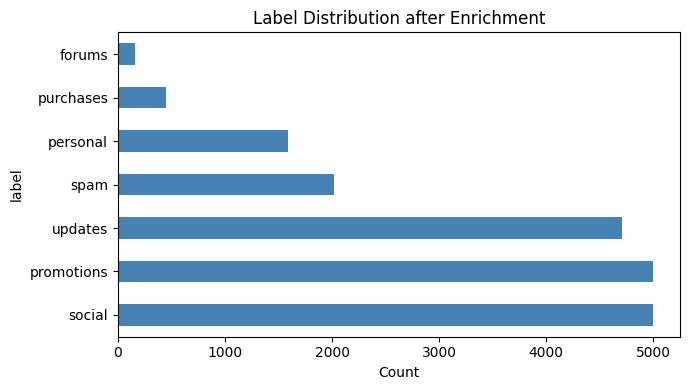

In [3]:
import matplotlib.pyplot as plt

df = pd.read_sql("SELECT label, COUNT(*) as n FROM emails GROUP BY label ORDER BY n DESC",
                 sqlite3.connect("emails.db"))
print(df.to_string(index=False))

df.set_index("label")["n"].plot(kind="barh", figsize=(7,4), color="steelblue")
plt.title("Label Distribution after Enrichment")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

## 4 — Rule-Based Spam Layer

**Why rules on top of ML?**  
Some spam signals are deterministic — a `.ru` domain combined with "FREE WINNER" in caps is spam regardless of what the model thinks. Rules are fast, explainable, and catch patterns the model hasn't seen. This hybrid approach (rules + ML) is how production spam filters like Gmail work.

In [4]:
SPAM_TLDS = {".ru", ".xyz", ".tk", ".ml", ".ga", ".cf", ".gq", ".top", ".click", ".loan"}

SPAM_KEYWORDS = {
    "winner", "won", "free", "claim", "prize", "congratulations",
    "click here", "limited time", "act now", "urgent", "verify your account",
    "you have been selected", "nigerian", "inheritance", "wire transfer",
    "100%", "guaranteed", "no risk", "make money", "earn cash",
}

def rule_based_spam_score(subject: str, body: str, sender: str = "") -> dict:
    """
    Returns a score 0-1 and triggered rules.
    Score >= 0.5 → override prediction to spam.
    """
    text  = (subject + " " + body).lower()
    score = 0.0
    rules = []

    # Suspicious TLD in sender or body links
    for tld in SPAM_TLDS:
        if tld in sender.lower() or tld in text:
            score += 0.4
            rules.append(f"suspicious TLD: {tld}")
            break

    # Spam keywords
    hits = [kw for kw in SPAM_KEYWORDS if kw in text]
    if hits:
        score += min(0.15 * len(hits), 0.45)
        rules.append(f"keywords: {hits[:3]}")

    # Excessive caps in subject (>40%)
    letters = [c for c in subject if c.isalpha()]
    if letters and sum(1 for c in letters if c.isupper()) / len(letters) > 0.4:
        score += 0.2
        rules.append("high caps ratio in subject")

    # Many exclamation marks
    if (subject + body).count("!") > 3:
        score += 0.15
        rules.append("excessive exclamation marks")

    return {"score": min(round(score, 2), 1.0), "rules": rules, "is_spam": score >= 0.5}


# Test it
examples = [
    ("Congratulations! You have won a FREE iPhone 15 - Click NOW to claim",
     "Click http://totally-legit.ru/claim to get your prize. LIMITED TIME!!!",
     "noreply@totally-legit.ru"),
    ("Deine Bestellung #12345 wurde versandt",
     "Hallo, deine Bestellung ist unterwegs.",
     "noreply@amazon.de"),
    ("LinkedIn: You have 3 new connection requests",
     "See who wants to connect with you.",
     "notifications@linkedin.com"),
]

for subject, body, sender in examples:
    result = rule_based_spam_score(subject, body, sender)
    print(f"Subject : {subject[:55]}")
    print(f"Result  : spam={result['is_spam']}  score={result['score']}  rules={result['rules']}")
    print()

Subject : Congratulations! You have won a FREE iPhone 15 - Click 
Result  : spam=True  score=1.0  rules=['suspicious TLD: .ru', "keywords: ['won', 'prize', 'free']", 'excessive exclamation marks']

Subject : Deine Bestellung #12345 wurde versandt
Result  : spam=False  score=0.0  rules=[]

Subject : LinkedIn: You have 3 new connection requests
Result  : spam=False  score=0.0  rules=[]

